In [1]:
import sys
from types import MethodType

sys.path.append(r"C:\Users\AlexanderZirn\Documents\GIT\nRTD\lib")
from pathlib import Path
import argparse

import numpy as np
import torch
import torch.utils
import torch.utils.data
import wandb
import lightning.pytorch as pl
from lightning.pytorch.loggers.wandb import WandbLogger
from lightning.pytorch.callbacks import LearningRateMonitor

torch.set_default_dtype(torch.float64)

from nRTD import RTDModule, RTDDataModule
#from SweepRunner import Sweeper
import matplotlib.pyplot as plt

plt.style.use("ICIWstyle")

In [2]:
def log_plots(data_module: RTDDataModule, model: RTDModule, index=0, Es_to_plot=[0]):
    pred_y, pred_t = model(data_module.x, data_module.t_in)
    pred_t = pred_t.detach().numpy().squeeze()
    pred_y = pred_y.detach().numpy().squeeze()

    fig = plt.figure()
    index = 0
    plt.plot(
        data_module.t_in[index],
        data_module.x[index].squeeze(),
        ls="--",
    )
    plt.plot(
        data_module.t_in[index + 2],
        data_module.x[index + 2].squeeze(),
        ls="--",
    )
    plt.plot(
        data_module.t_out[index],
        data_module.y[index].squeeze(),
        "o",
        c="C0",
        markersize=0.5,
    )
    plt.plot(
        data_module.t_out[index + 2],
        data_module.y[index + 2].squeeze(),
        "o",
        c="C1",
        markersize=0.5,
    )
    plt.plot(
        data_module.t_in[index + 1],
        data_module.x[index + 1].squeeze(),
        ls="--",
        c="C2",
    )
    plt.plot(
        data_module.t_in[index + 3],
        data_module.x[index + 3].squeeze(),
        ls="--",
        c="C3",
    )
    plt.plot(
        data_module.t_out[index + 1],
        data_module.y[index + 1].squeeze(),
        "o",
        c="C2",
        markersize=0.5,
    )
    plt.plot(
        data_module.t_out[index + 3],
        data_module.y[index + 3].squeeze(),
        "o",
        c="C3",
        markersize=0.5,
    )

    plt.plot(pred_t[index, :], pred_y[index, :], c="C0")
    plt.plot(pred_t[index + 2].squeeze(), pred_y[index + 2].squeeze(), c="C1")
    plt.plot(pred_t[index + 1, :], pred_y[index + 1, :], c="C2")
    plt.plot(pred_t[index + 3].squeeze(), pred_y[index + 3].squeeze(), c="C3")
    plt.xlabel("t / s")
    plt.ylabel("x / 1")
    plt.twinx()
    ax = plt.gca()
    plt.ylabel("$E \;/\; s^{-1}$")
    my_colors = ["darkmagenta", "goldenrod", "firebrick", "darkcyan"]
    for E_index in Es_to_plot:
        ax.plot(
            model.net.conv_layers[E_index].t_kernel.detach().numpy(),
            model.net.E[E_index],
            color=my_colors[E_index],
        )
    wandb.log({f"RTD_Plot_img": wandb.Image(fig)})
    wandb.log({f"RTD_Plot_fig": fig})

In [3]:
### Constants
# givens
t_out = (0.0, 120.0)
print(f"t_out: {t_out}")
n_out = int(4 * (t_out[1] - t_out[0]) + 1)
print(f"n_out: {n_out}")
delta_t_out = (t_out[1] - t_out[0]) / (n_out - 1)
print(f"delta_t_out: {delta_t_out}")
# # the capillary times
# # FBA_18032025_300ml-min_Analytik_MS
# switching_periods = np.array(
#     [
#         5 * 60 + 0.03,
#         5 * 60 + 0.27,
#         5 * 60 + 0.27,
#         5 * 60 + 0.28,
#         5 * 60 + 0.18,
#         5 * 60 + 0.26,
#         5 * 60 + 0.33,
#         5 * 60 + 0.27,
#         5 * 60 + 0.18,
#         5 * 60 + 0.05,
#     ]
# )
# switching_times_cap = np.flip(np.cumsum(-switching_periods))
# switching_times_cap = np.append(switching_times_cap, 0) - 1

# the piping times
t_halfperiod = t_out[1] - t_out[0]
print(f"t_halfperiod: {t_halfperiod}")

# automated_switching_times = np.full((20,), t_halfperiod)
# switching_times_reac_inlet = np.insert(automated_switching_times, 0, 7.4 - 1.0)
# switching_times_reac_inlet = np.cumsum(switching_times_reac_inlet)
# switching_times_reac_outlet = np.insert(automated_switching_times, 0, 7.5 - 1.0)
# switching_times_reac_outlet = np.cumsum(switching_times_reac_outlet)
# switching_times_total_system = np.insert(automated_switching_times, 0, 7.7 - 1.0)
# switching_times_total_system = np.cumsum(switching_times_total_system)

t_kernels = [
    #(0.0, 30.0),  # piping to reactor inlet
    #(0.0, 40.0),  # reactor
    #(0.0, 60.0)#,  # piping after reactor outlet
    (0.0, 70.0),  # capillary
]
print(f"t_kernels: {t_kernels}")

n_kernels = list(
    map(
        lambda t_kernel: int(((t_kernel[1] - t_kernel[0]) / delta_t_out) + 1), t_kernels
    )
)
print(f"n_kernels: {n_kernels}")
t_in = (0, t_out[1] - sum([t_kernel[1] for t_kernel in t_kernels]))
print(f"t_in: {t_in}")
n_in = int(((t_in[1] - t_in[0]) / delta_t_out) + 1)
print(f"n_in: {n_in}")

t_out: (0.0, 120.0)
n_out: 481
delta_t_out: 0.25
t_halfperiod: 120.0
t_kernels: [(0.0, 70.0)]
n_kernels: [281]
t_in: (0, 50.0)
n_in: 201


In [4]:
# create array with half-period times

t_offset = 872.0550000000003#-1 # 14*60+30 # offset until experiment starts
#t_halfperiod = 300 # 5min half-period duration

switching_times = np.full((10,), 5*60) + np.array([0.05,
                                                          0.18,
                                                          0.27,
                                                          0.33,
                                                          0.26,
                                                          0.18,
                                                          0.28,
                                                          0.27,
                                                          0.27,
                                                          0.03])# 24 half-periods
print(switching_times)
switching_times = np.insert(switching_times, 0, t_offset)
switching_times = np.cumsum(switching_times)
print(switching_times)

intervals = [
    (switching_times[i], switching_times[i + 1])
    for i in range(len(switching_times) - 1)
]
print(intervals)

[300.05 300.18 300.27 300.33 300.26 300.18 300.28 300.27 300.27 300.03]
[ 872.055 1172.105 1472.285 1772.555 2072.885 2373.145 2673.325 2973.605
 3273.875 3574.145 3874.175]
[(np.float64(872.0550000000003), np.float64(1172.1050000000002)), (np.float64(1172.1050000000002), np.float64(1472.2850000000003)), (np.float64(1472.2850000000003), np.float64(1772.5550000000003)), (np.float64(1772.5550000000003), np.float64(2072.885)), (np.float64(2072.885), np.float64(2373.1450000000004)), (np.float64(2373.1450000000004), np.float64(2673.3250000000003)), (np.float64(2673.3250000000003), np.float64(2973.6050000000005)), (np.float64(2973.6050000000005), np.float64(3273.8750000000005)), (np.float64(3273.8750000000005), np.float64(3574.1450000000004)), (np.float64(3574.1450000000004), np.float64(3874.175))]


In [5]:
wandb.init(project="HSA_MGA_nRTD", entity="ice_ulm")

wandb: Currently logged in as: alexander-zirn (ice_ulm) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [6]:
import sys

sys.path.append(r"C:\Users\AlexanderZirn\Documents\GIT\nRTD\lib")
from pathlib import Path
from nRTD.rtd_fitting import RTDDataModule

data_cap = RTDDataModule(
    batch_size= 32, # 2 temperatures, 2 half-periods, 4 different capillary positions
    data_file=Path(
        r"C:\Users\AlexanderZirn\Documents\GIT\nRTD\Experiments\AZA_001\A - capillary\AZA-E-130625_250ml-min_2bar_250_Capillary.npz"
    ),
    switching_times=switching_times,
    t_range_in=t_in,
    n_in=n_in,
    t_range_out=t_out,
    n_out=n_out,
    switch_delay=0.5,
)

def patch_setup(self, stage: str):
    import scipy

    print("Setup")
    # load the raw data from disc
    with np.load(self.data_file) as data:
        n_dot = data["n_dot"]
        times = data["time_delta"]

    # interpolate the data to the measured time scale
    interp = scipy.interpolate.interp1d(
        times,
        n_dot,
        kind="linear",
        fill_value="extrapolate",
    )
    # calculate the time scales for the input and output data
    t_in = np.linspace(
        self.t_range_in[0],
        self.t_range_in[1],
        self.n_in,
    )
    t_out = np.linspace(
        self.t_range_out[0],
        self.t_range_out[1],
        self.n_out,
    )
    delta_t = (self.t_range_out[1] - self.t_range_out[0]) / (self.n_out - 1)

    # for each interval in ther switching periods, interpolate the data on that interval
    for i, interval in enumerate(self.intervals):
        # check if the period is even or odd
        even_period = i % 2 == 0
        # begin of interpolation
        interp_begin = interval[0] + self.t_range_out[0]
        # end of interpolation
        interp_end = interp_begin + self.t_range_out[-1]
        # auxilliray time scale for the interpolation
        # 15 seconds of the end of each signal will be repeated to pad out the signal to 2 min
        interp_aux = interp_begin + 30
        # available time scale for interpolation
        #  hard coded 15 seconds
        interp_avail = interp_begin + 45

        t_interp = np.linspace(
            interp_begin,
            interp_end,
            self.n_out,
        )
        n_avail = int((interp_avail - interp_begin) / delta_t + 1)
        t_avail = np.linspace(
            interp_begin,
            interp_avail,
            n_avail,
        )
        n_aux = int((interp_avail - interp_aux) / delta_t)
        t_aux = np.linspace(
            interp_aux,
            interp_avail,
            n_aux,
        )

        # we only care about Ar and He as tracers
        n_dot_interp_avail = interp(t_avail)[
            [0, 1]
        ]  # shape is (2, n_out) that is two valid samples
        n_dot_interp_aux = interp(t_aux)[[0, 1]]
        n_dot_interp_aux = np.tile(n_dot_interp_aux, (1, 5))
        n_dot_interp = np.concatenate([n_dot_interp_avail, n_dot_interp_aux], axis=1)

        # get the respective 0 and 1 values for the switch
        if even_period:
            try:
                even_steady_state_values = np.append(
                    even_steady_state_values, n_dot_interp[None, :, [0, -1]], axis=0
                )
            except NameError:
                even_steady_state_values = n_dot_interp[None, :, [0, -1]]
        else:
            try:
                odd_steady_state_values = np.append(
                    odd_steady_state_values, n_dot_interp[None, :, [0, -1]], axis=0
                )
            except NameError:
                odd_steady_state_values = n_dot_interp[None, :, [0, -1]]

        # stack the interpolated data
        try:
            y = np.vstack((y, n_dot_interp))
        except NameError:
            y = n_dot_interp

    #  take the mean over all samples to get somewhat reliable steady state values
    even_steady_state_values = even_steady_state_values.mean(
        axis=0
    )  # shape (2,2) first index is species, second index is the steady state
    odd_steady_state_values = odd_steady_state_values.mean(axis=0)

    # claculate the step functions for each interval
    for i, interval in enumerate(self.intervals):
        # check if the period is even or odd
        even_period = i % 2 == 0

        if even_period:
            steady_state_values = even_steady_state_values
        else:
            steady_state_values = odd_steady_state_values

        n_dot_in = np.zeros((2, self.n_in))
        n_dot_in[0, :] = np.where(
            t_in < self.switch_delay,
            steady_state_values[0, 0],
            steady_state_values[0, 1],
        )
        n_dot_in[1, :] = np.where(
            t_in < self.switch_delay,
            steady_state_values[1, 0],
            steady_state_values[1, 1],
        )

        # stack the step functions
        try:
            x = np.vstack((x, n_dot_in))
        except NameError:
            x = n_dot_in
    self.y = torch.Tensor(y)[:, None, :]
    self.x = torch.tensor(x)[:, None, :]
    t_in = torch.tensor(t_in)
    t_out = torch.tensor(t_out)
    self.t_in = torch.tile(t_in, (2 * len(self.intervals), 1))
    self.t_out = torch.tile(t_out, (2 * len(self.intervals), 1))
    self.data_set = torch.utils.data.TensorDataset(self.x, self.t_in, self.y)
    self.train_set, self.test_set = torch.utils.data.random_split(
        self.data_set,
        [
            int(0.8 * len(self.data_set)),
            len(self.data_set) - int(0.8 * len(self.data_set)),
        ],
    )


data_cap.setup = MethodType(patch_setup, data_cap)

In [7]:
data_cap.setup("fit")
data_cap.x[0]

Setup


tensor([[3.3264e-06, 3.3264e-06, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02,
         3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02,
         3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02,
         3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02,
         3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02,
         3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02,
         3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02,
         3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02,
         3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02,
         3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02,
         3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02,
         3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02, 3.3084e-02,
         3.3084e-02, 3.3084e

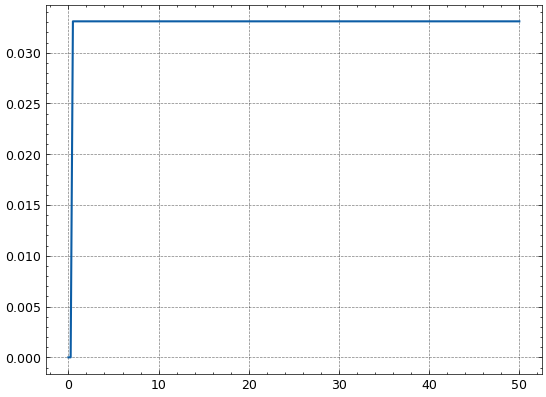

In [8]:
%matplotlib inline
plt.plot(data_cap.t_in[0,:], data_cap.x[0,0,:])
plt.show()
plt.close()

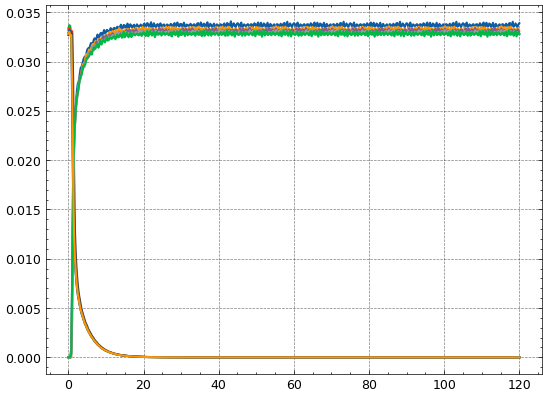

In [9]:
# plot t_in über x
%matplotlib inline
plt.figure()

for i in np.arange(0,20):
    if i %2==0:
        plt.plot(data_cap.t_out[i, :], data_cap.y[i, 0, ...], label="Ar")
plt.show()
plt.close()

In [10]:
model = RTDModule(
    kernel_sizes = n_kernels,
    kernel_times = t_kernels,
    learning_rate = 4e-3,
    use_scheduler = False,
    scheduler_kwargs = {"factor": 0.6, "patience": 2000},
)

In [11]:
# #%pip install litmodels
#from litmodels import LitModelCheckpoint
# #import litmodels

my_logger = WandbLogger(log_model=True)
lr_callback = LearningRateMonitor()

max_epochs = 20_000

trainer = pl.Trainer(
    accelerator="cpu",
    max_epochs=max_epochs,
    enable_progress_bar=True,
    logger=my_logger,
    callbacks=[lr_callback],
)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [12]:
model.configure_optimizers()

{'optimizer': Adam (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     decoupled_weight_decay: False
     differentiable: False
     eps: 1e-08
     foreach: None
     fused: None
     lr: 0.004
     maximize: False
     weight_decay: 0
 )}

In [13]:
trainer.fit(model, data_cap)

C:\Users\AlexanderZirn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
C:\Users\AlexanderZirn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lightning\pytorch\loggers\wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.

  | Name | Type   | Params | Mode 
----------------------------------------
0 | net  | RTDNet | 281    | train
----------------------------------------
281       Trainable params
0         Non-trainable params
281       Total params
0.001     Total estimated model params size (MB)
4         Modules in train mode
0         Modules in eva

Setup
Epoch 19999: 100%|██████████| 1/1 [00:00<00:00, 35.30it/s, v_num=5qkh, train/loss=9.41e-7] 

`Trainer.fit` stopped: `max_epochs=20000` reached.


Epoch 19999: 100%|██████████| 1/1 [00:00<00:00, 22.23it/s, v_num=5qkh, train/loss=9.41e-7]


In [14]:
%pip install plotly


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: C:\Users\AlexanderZirn\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [15]:
log_plots(
    data_module=data_cap,
    model=model,
    index=0,
    Es_to_plot=[0]#, 1, 2, 3],
)
plt.savefig("RTD capillary.svg", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>